# Tugas Praktikum #3 — Multiprocessing

**Nama :** DWIMIRZA INTANIA ARSY
**NIM  :** 2411513007  
PEMOGRAMAN PARALEL A 
Dosen Pengampu : DESTA YOLANDA, M.T



---
## Soal 1 — Analisis Speedup Skala (`hitung_prima`, worker = 1, 2, 4, 8)

**Rencana:** mengulang eksperimen 7.1 di materi, memakai fungsi `hitung_prima(n)` yang sama, dengan
`mp.get_context('fork').Pool(processes=...)` untuk worker = 1, 2, 4, 8.

Beberapa keputusan desain:
- Jumlah tugas dibuat **8 tugas** (bukan 4 seperti materi) dengan `n = 120.000` agar 8 worker masing-masing kebagian satu tugas
  dan pekerjaan cukup berat sehingga overhead tidak mendominasi.
- Setiap konfigurasi diulang **3 kali**, lalu diambil waktu **tercepat** (mengurangi gangguan proses lain di mesin).
- Speedup dihitung terhadap **baseline sekuensial** (tanpa Pool): `speedup = waktu_sekuensial / waktu_paralel`.
- Kurva teoritis memakai **Hukum Amdahl**: `S(N) = 1 / ((1 - P) + P / N)`, dengan `P` = porsi yang bisa diparalelkan.

In [1]:
import multiprocessing as mp
import os
import time

def jumlah_core():
    # core yang benar-benar boleh dipakai proses ini (lebih akurat dari os.cpu_count() di container)
    if hasattr(os, "sched_getaffinity"):
        return len(os.sched_getaffinity(0))
    return os.cpu_count() or 1

CORE = jumlah_core()
print(f"Core yang tersedia untuk notebook ini: {CORE} (os.cpu_count() = {os.cpu_count()})")

def hitung_prima(n):
    # Menghitung semua bilangan prima hingga n (algoritma sederhana, sama seperti di materi)
    primes = []
    for num in range(2, n):
        is_prime = True
        for i in range(2, int(num ** 0.5) + 1):
            if num % i == 0:
                is_prime = False
                break
        if is_prime:
            primes.append(num)
    return len(primes)

JUMLAH_TUGAS = 8
daftar_n = [120_000] * JUMLAH_TUGAS
daftar_worker = [1, 2, 4, 8]
ULANG = 3

def ukur_sequential():
    start = time.perf_counter()
    hasil = [hitung_prima(n) for n in daftar_n]
    return time.perf_counter() - start, hasil

def ukur_pool(jumlah_worker):
    ctx = mp.get_context("fork")
    start = time.perf_counter()
    with ctx.Pool(processes=jumlah_worker) as pool:
        hasil = pool.map(hitung_prima, daftar_n)
    return time.perf_counter() - start, hasil

if __name__ == "__main__":
    # --- baseline sekuensial ---
    percobaan = [ukur_sequential() for _ in range(ULANG)]
    waktu_seq = min(w for w, _ in percobaan)
    hasil_seq = percobaan[0][1]
    print(f"[Sequential] hasil: {hasil_seq}  waktu terbaik: {waktu_seq:.2f} detik\n")

    # --- paralel dengan berbagai jumlah worker ---
    waktu_pool = {}
    for w in daftar_worker:
        percobaan = [ukur_pool(w) for _ in range(ULANG)]
        waktu_pool[w] = min(t for t, _ in percobaan)
        assert percobaan[0][1] == hasil_seq      # hasil paralel harus sama dengan sekuensial
        print(f"[Pool, worker = {w}] waktu terbaik: {waktu_pool[w]:.2f} detik")

Core yang tersedia untuk notebook ini: 1 (os.cpu_count() = 1)
[Sequential] hasil: [11301, 11301, 11301, 11301, 11301, 11301, 11301, 11301]  waktu terbaik: 0.83 detik

[Pool, worker = 1] waktu terbaik: 0.84 detik
[Pool, worker = 2] waktu terbaik: 0.85 detik
[Pool, worker = 4] waktu terbaik: 0.83 detik
[Pool, worker = 8] waktu terbaik: 0.88 detik


Core tersedia: 1

worker | waktu (s) |  aktual | Amdahl P=1 | batas core | efisiensi
------------------------------------------------------------------
     1 |      0.84 |   0.99x |      1.00x |      1.00x |       99%
     2 |      0.85 |   0.97x |      2.00x |      1.00x |       49%
     4 |      0.83 |   1.00x |      4.00x |      1.00x |       25%
     8 |      0.88 |   0.95x |      8.00x |      1.00x |       12%

Speedup aktual tertinggi: 1.00x pada 4 worker.
Mesin ini hanya punya 1 core, jadi speedup aktual tidak mungkin jauh melebihi 1x, sedangkan Amdahl (P=1) memprediksi 8x untuk 8 worker.
Terlihat juga bahwa menambah worker melebihi jumlah core tidak menambah kecepatan (justru bisa menurun).


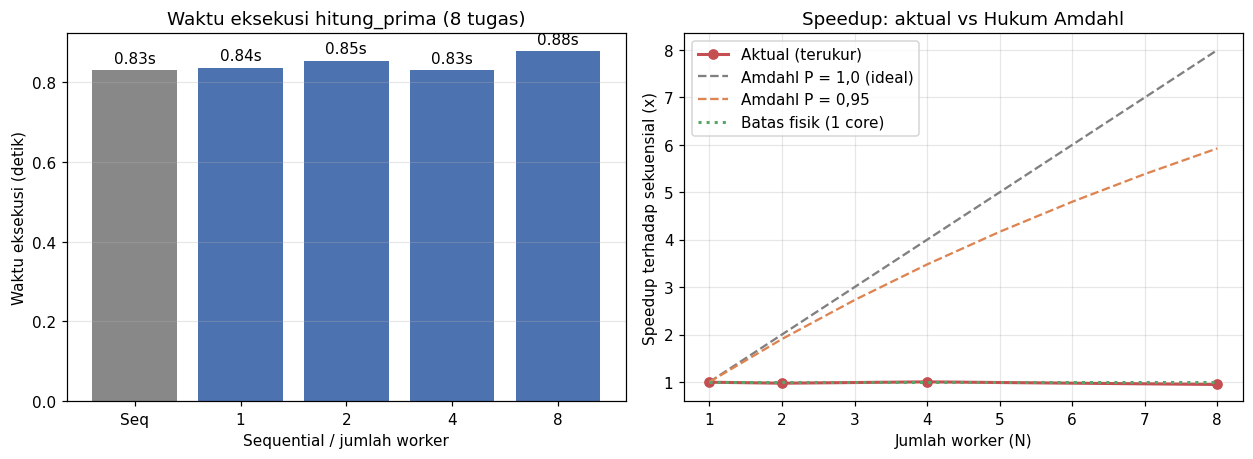

In [2]:
import matplotlib.pyplot as plt

def amdahl(P, N):
    return 1 / ((1 - P) + P / N)

speedup_aktual = {w: waktu_seq / waktu_pool[w] for w in daftar_worker}

print(f"Core tersedia: {CORE}\n")
print(f"{'worker':>6} | {'waktu (s)':>9} | {'aktual':>7} | {'Amdahl P=1':>10} | {'batas core':>10} | {'efisiensi':>9}")
print("-" * 66)
for w in daftar_worker:
    batas = min(w, CORE)
    print(f"{w:>6} | {waktu_pool[w]:>9.2f} | {speedup_aktual[w]:>6.2f}x | {amdahl(1.0, w):>9.2f}x | "
          f"{batas:>9.2f}x | {speedup_aktual[w] / w * 100:>8.0f}%")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.3))

# Panel 1: waktu eksekusi
labels = ["Seq"] + [str(w) for w in daftar_worker]
waktu_semua = [waktu_seq] + [waktu_pool[w] for w in daftar_worker]
warna = ["#888888"] + ["#4C72B0"] * len(daftar_worker)
bars = ax1.bar(labels, waktu_semua, color=warna)
for b, w in zip(bars, waktu_semua):
    ax1.text(b.get_x() + b.get_width() / 2, w + 0.01, f"{w:.2f}s", ha="center", va="bottom")
ax1.set_xlabel("Sequential / jumlah worker")
ax1.set_ylabel("Waktu eksekusi (detik)")
ax1.set_title("Waktu eksekusi hitung_prima (8 tugas)")
ax1.grid(axis="y", alpha=0.3)

# Panel 2: speedup vs worker
xs = list(range(1, 9))
ax2.plot(daftar_worker, [speedup_aktual[w] for w in daftar_worker], "o-", color="#C44E52", linewidth=2, label="Aktual (terukur)")
ax2.plot(xs, [amdahl(1.0, n) for n in xs], "--", color="gray", label="Amdahl P = 1,0 (ideal)")
ax2.plot(xs, [amdahl(0.95, n) for n in xs], "--", color="#DD8452", label="Amdahl P = 0,95")
ax2.plot(xs, [min(n, CORE) for n in xs], ":", color="#55A868", linewidth=2, label=f"Batas fisik ({CORE} core)")
ax2.set_xlabel("Jumlah worker (N)")
ax2.set_ylabel("Speedup terhadap sekuensial (x)")
ax2.set_title("Speedup: aktual vs Hukum Amdahl")
ax2.set_xticks(xs)
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Ringkasan otomatis (menyesuaikan mesin yang dipakai)
terbaik = max(speedup_aktual, key=speedup_aktual.get)
print(f"\nSpeedup aktual tertinggi: {speedup_aktual[terbaik]:.2f}x pada {terbaik} worker.")
if CORE < max(daftar_worker):
    print(f"Mesin ini hanya punya {CORE} core, jadi speedup aktual tidak mungkin jauh melebihi {CORE}x, "
          f"sedangkan Amdahl (P=1) memprediksi {amdahl(1.0, 8):.0f}x untuk 8 worker.")
if speedup_aktual[8] < speedup_aktual[terbaik]:
    print("Terlihat juga bahwa menambah worker melebihi jumlah core tidak menambah kecepatan (justru bisa menurun).")

Penjelasan Soal 1

Pada percobaan ini, perhitungan bilangan prima dijalankan dengan jumlah worker yang berbeda, yaitu 1, 2, 4, dan 8. Tujuannya adalah melihat apakah penambahan jumlah proses dapat mempercepat waktu pengerjaan.

Speedup dihitung dengan membandingkan waktu ketika menggunakan 1 worker dengan waktu ketika menggunakan jumlah worker lainnya. Semakin besar nilai speedup, berarti proses berjalan semakin cepat dibandingkan penggunaan satu worker.

Pada grafik terdapat speedup aktual dan speedup ideal. Kondisi ideal menganggap bahwa penambahan worker akan membuat pekerjaan menjadi lebih cepat secara sempurna. Namun, hasil aktual biasanya tidak sama dengan garis ideal.

Perbedaannya dapat disebabkan oleh jumlah core fisik CPU yang tersedia. Selain itu, sistem membutuhkan waktu untuk membuat dan mengatur proses (overhead). Komputer juga dapat menjalankan proses lain secara bersamaan sehingga sumber daya CPU terbagi.

---
## Soal 2 — Shared Memory vs Message Passing

**Tugas:** 4 proses, masing-masing menjumlahkan **1 juta angka acak**. Bandingkan:

- **(a) `Queue` (message passing):** tiap proses menjumlahkan angkanya sendiri, lalu mengirim **subtotal** lewat queue. Main process menjumlahkan 4 subtotal.
- **(b) `Value` + `Lock` (shared memory):** tiap proses **langsung menambahkan** ke satu nilai bersama. Karena `+=` tidak atomik, penambahan dilindungi lock.

Agar hasilnya bisa diverifikasi, angka acak dibangkitkan dengan `random.Random(seed)` (seed = nomor proses), sehingga totalnya bisa dihitung ulang secara sekuensial.
Kita juga menambahkan dua varian pembanding: **(b0)** `Value` **tanpa** lock, dan **(b2)** `Value` + lock dengan **akumulasi lokal**
(dijumlah dulu di variabel lokal, baru satu kali ditambahkan ke shared value).

In [3]:
import multiprocessing as mp
import random
import time

JUMLAH_PROSES = 4
JUMLAH_ANGKA = 1_000_000
ctx = mp.get_context("fork")

def buat_angka(seed):
    rng = random.Random(seed)
    return [rng.randint(1, 100) for _ in range(JUMLAH_ANGKA)]

# nilai yang benar (dihitung sekuensial) untuk verifikasi
TOTAL_BENAR = sum(sum(buat_angka(s)) for s in range(JUMLAH_PROSES))
print(f"Total yang seharusnya (verifikasi sekuensial): {TOTAL_BENAR:,}\n")

# ---------- (a) Message passing: Queue ----------
def worker_queue(seed, q):
    subtotal = sum(buat_angka(seed))
    q.put(subtotal)                      # kirim subtotal ke main process

def versi_queue():
    q = ctx.Queue()
    proses = [ctx.Process(target=worker_queue, args=(s, q)) for s in range(JUMLAH_PROSES)]
    start = time.perf_counter()
    for p in proses:
        p.start()
    subtotal = [q.get() for _ in proses]  # ambil hasil DULU sebelum join
    for p in proses:
        p.join()
    total = sum(subtotal)                 # reduce di main process
    return total, time.perf_counter() - start

# ---------- (b) Shared memory: Value + Lock, langsung tambah per angka ----------
def worker_value(seed, total):
    for x in buat_angka(seed):
        with total.get_lock():            # critical section: seluruh read-modify-write
            total.value += x

# ---------- (b0) Shared memory TANPA lock (sengaja salah, untuk demonstrasi) ----------
def worker_value_tanpa_lock(seed, total):
    for x in buat_angka(seed):
        total.value += x                  # read-modify-write TIDAK atomik

# ---------- (b2) Shared memory + Lock, akumulasi lokal (optimasi) ----------
def worker_value_lokal(seed, total):
    subtotal = sum(buat_angka(seed))      # hitung dulu secara lokal (tanpa lock)
    with total.get_lock():                # hanya 1x akses ke shared value
        total.value += subtotal

def versi_value(target):
    total = ctx.Value("q", 0)             # 'q' = 64-bit signed integer
    proses = [ctx.Process(target=target, args=(s, total)) for s in range(JUMLAH_PROSES)]
    start = time.perf_counter()
    for p in proses:
        p.start()
    for p in proses:
        p.join()
    return total.value, time.perf_counter() - start

def ukur(fungsi, ulang=2):
    hasil = [fungsi() for _ in range(ulang)]
    return min(hasil, key=lambda x: x[1])  # ambil percobaan tercepat

if __name__ == "__main__":
    varian = {
        "(a)  Queue (message passing)":            lambda: versi_queue(),
        "(b)  Value + Lock (per angka)":           lambda: versi_value(worker_value),
        "(b2) Value + Lock (akumulasi lokal)":     lambda: versi_value(worker_value_lokal),
        "(b0) Value TANPA Lock (salah)":           lambda: versi_value(worker_value_tanpa_lock),
    }
    hasil_ukur = {}
    for nama, f in varian.items():
        total, waktu = ukur(f)
        hasil_ukur[nama] = (total, waktu)
        status = "BENAR" if total == TOTAL_BENAR else f"SALAH (selisih {total - TOTAL_BENAR:+,})"
        print(f"{nama:<40} total = {total:>13,}  waktu = {waktu:6.2f} s  -> {status}")

Total yang seharusnya (verifikasi sekuensial): 202,026,957

(a)  Queue (message passing)             total =   202,026,957  waktu =   1.34 s  -> BENAR
(b)  Value + Lock (per angka)            total =   202,026,957  waktu =   4.24 s  -> BENAR
(b2) Value + Lock (akumulasi lokal)      total =   202,026,957  waktu =   1.36 s  -> BENAR
(b0) Value TANPA Lock (salah)            total =    86,289,197  waktu =   2.85 s  -> SALAH (selisih -115,737,760)


Value+Lock per angka  vs Queue            : 3.2x lebih lambat
Value+Lock akumulasi lokal vs Queue        : 1.01x (rasio waktu)
Lock per angka  vs akumulasi lokal        : 3.1x lebih lambat


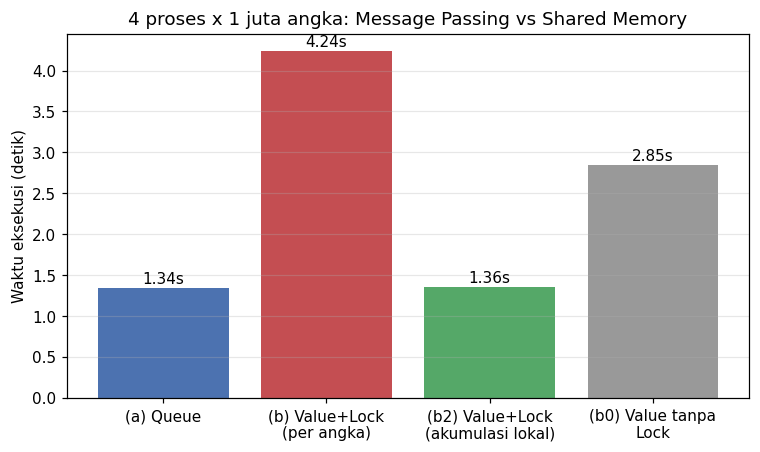

In [4]:
import matplotlib.pyplot as plt

nama_pendek = {
    "(a)  Queue (message passing)": "(a) Queue",
    "(b)  Value + Lock (per angka)": "(b) Value+Lock\n(per angka)",
    "(b2) Value + Lock (akumulasi lokal)": "(b2) Value+Lock\n(akumulasi lokal)",
    "(b0) Value TANPA Lock (salah)": "(b0) Value tanpa\nLock",
}
label = [nama_pendek[n] for n in hasil_ukur]
waktu = [hasil_ukur[n][1] for n in hasil_ukur]
warna = ["#4C72B0", "#C44E52", "#55A868", "#999999"]

plt.figure(figsize=(8, 4.3))
bars = plt.bar(label, waktu, color=warna)
for b, w in zip(bars, waktu):
    plt.text(b.get_x() + b.get_width() / 2, w + 0.05, f"{w:.2f}s", ha="center")
plt.ylabel("Waktu eksekusi (detik)")
plt.title("4 proses x 1 juta angka: Message Passing vs Shared Memory")
plt.grid(axis="y", alpha=0.3)
plt.show()

w_q = hasil_ukur["(a)  Queue (message passing)"][1]
w_v = hasil_ukur["(b)  Value + Lock (per angka)"][1]
w_l = hasil_ukur["(b2) Value + Lock (akumulasi lokal)"][1]
print(f"Value+Lock per angka  vs Queue            : {w_v / w_q:.1f}x lebih lambat")
print(f"Value+Lock akumulasi lokal vs Queue        : {w_l / w_q:.2f}x (rasio waktu)")
print(f"Lock per angka  vs akumulasi lokal        : {w_v / w_l:.1f}x lebih lambat")

Penjelasan Soal 2

Pada percobaan ini digunakan 4 proses yang masing-masing menghitung jumlah dari 1 juta angka acak. Percobaan dilakukan dengan dua cara, yaitu menggunakan Queue dan menggunakan Value dengan Lock. Tujuannya adalah untuk melihat perbedaan cara kedua metode tersebut dalam berbagi hasil antarproses serta membandingkan waktu eksekusinya.

Pada metode Queue, setiap proses melakukan perhitungan secara masing-masing. Setelah selesai, hasil perhitungan dari setiap proses dikirim ke dalam Queue. Selanjutnya, proses utama mengambil hasil dari keempat proses tersebut dan menjumlahkannya untuk mendapatkan total akhir. Metode ini termasuk message passing karena proses saling bertukar data dengan cara mengirimkan hasil melalui Queue.

Sedangkan pada metode Value dan Lock, hasil perhitungan dari setiap proses langsung ditambahkan ke satu nilai yang digunakan bersama. Karena nilai tersebut dapat diakses oleh beberapa proses, digunakan Lock agar proses yang sedang mengubah nilai tidak dilakukan secara bersamaan dengan proses lain. Dengan begitu, hasil yang tersimpan tetap konsisten dan tidak terjadi perubahan nilai yang saling bertabrakan.

Dari kedua percobaan tersebut, waktu eksekusi kemudian dibandingkan untuk melihat metode mana yang membutuhkan waktu lebih sedikit pada kondisi pengujian. Perbedaan waktu dapat terjadi karena Queue membutuhkan proses pengiriman dan pengambilan data, sedangkan Value menggunakan data yang dibagikan secara langsung. Namun, penggunaan Value juga membutuhkan pengaturan Lock, sehingga waktu eksekusi tidak hanya dipengaruhi oleh metode penyimpanan data, tetapi juga oleh proses sinkronisasi antarproses. Hasil waktu yang diperoleh juga dapat berbeda pada setiap komputer karena dipengaruhi oleh kondisi CPU dan proses lain yang sedang berjalan.

---
## Soal 3 — Producer-Consumer Antar-Proses

**Tugas:** mengubah producer-consumer `queue.Queue` + `threading.Thread` (Pertemuan 2) menjadi `multiprocessing.Queue` + `multiprocessing.Process`,
lalu membandingkan struktur kode dan performa untuk tugas **CPU-bound**.

Kita bangun **tiga** versi dengan pola sama (1 producer, 3 consumer, sinyal berhenti `None` yang diteruskan antar-consumer):

1. **Sekuensial**: sebagai pembanding.
2. **Versi thread** (Pertemuan 2): `threading.Thread` + `queue.Queue`.
3. **Versi proses** (Pertemuan 3): `multiprocessing.Process` + `multiprocessing.Queue`.

Fungsi kerja diganti sesuai jenis tugas: **CPU-bound** memakai `hitung_prima(100_000)`, sedangkan **I/O-bound** (seperti Pertemuan 2) memakai `time.sleep(0.1)`.

### 3a. Perbedaan struktur kode
Satu hal yang berbeda mendasar: **memori tidak dibagikan antar proses**. Kita buktikan dulu:

In [5]:
import multiprocessing as mp
import threading

daftar_bersama = []

def tambah_ke_list(nilai):
    daftar_bersama.append(nilai)

# --- Thread: memori dibagikan ---
t = threading.Thread(target=tambah_ke_list, args=("dari thread",))
t.start(); t.join()
print("Setelah thread selesai  :", daftar_bersama)

# --- Process: memori TIDAK dibagikan (child mengubah SALINAN miliknya) ---
p = mp.get_context("fork").Process(target=tambah_ke_list, args=("dari proses",))
p.start(); p.join()
print("Setelah proses selesai  :", daftar_bersama, "  <- 'dari proses' tidak muncul!")

Setelah thread selesai  : ['dari thread']
Setelah proses selesai  : ['dari thread']   <- 'dari proses' tidak muncul!


Konsekuensinya: pada versi proses, hasil kerja consumer **tidak bisa** disimpan ke list biasa seperti pada versi thread. Hasilnya harus dikirim balik
lewat **queue kedua** (`q_hasil`). Sekarang kita tulis kedua versi.

In [ ]:
import threading, queue
import multiprocessing as mp
import time

ctx = mp.get_context("fork")
JUMLAH_CONSUMER = 3

# ============================================================
# Fungsi kerja (dipakai oleh semua versi)
# ============================================================
def hitung_prima(n):
    primes = []
    for num in range(2, n):
        is_prime = True
        for i in range(2, int(num ** 0.5) + 1):
            if num % i == 0:
                is_prime = False
                break
        if is_prime:
            primes.append(num)
    return len(primes)

def kerja_cpu(n):          # CPU-bound
    return hitung_prima(n)

def kerja_io(durasi):      # I/O-bound (simulasi menunggu jaringan/disk)
    time.sleep(durasi)
    return durasi

# ============================================================
# VERSI THREAD (Pertemuan 2)
# ============================================================
def producer_thread(q, daftar_item):
    for item in daftar_item:
        q.put(item)
    q.put(None)                         # sinyal selesai

def consumer_thread(q, kerja, hasil_saya):
    while True:
        item = q.get()
        if item is None:
            q.put(None)                 # teruskan sinyal ke consumer lain
            break
        hasil_saya.append(kerja(item))  # tiap consumer menulis ke list miliknya sendiri
        q.task_done()

def jalankan_thread(daftar_item, kerja):
    q = queue.Queue()
    hasil_per_consumer = [[] for _ in range(JUMLAH_CONSUMER)]
    t_prod = threading.Thread(target=producer_thread, args=(q, daftar_item))
    t_cons = [threading.Thread(target=consumer_thread, args=(q, kerja, hasil_per_consumer[i]))
              for i in range(JUMLAH_CONSUMER)]
    start = time.perf_counter()
    t_prod.start()
    for t in t_cons: t.start()
    t_prod.join()
    for t in t_cons: t.join()
    waktu = time.perf_counter() - start
    return waktu, sorted(x for daftar in hasil_per_consumer for x in daftar)

# ============================================================
# VERSI PROSES (Pertemuan 3): perhatikan bagian yang BERUBAH
# ============================================================
def producer_proses(q, daftar_item):                      # (sama persis)
    for item in daftar_item:
        q.put(item)
    q.put(None)

def consumer_proses(q, q_hasil, kerja):                   # + q_hasil: hasil dikirim balik lewat queue
    while True:
        item = q.get()
        if item is None:
            q.put(None)                                   # teruskan sinyal ke consumer lain
            break
        q_hasil.put(kerja(item))                          # BUKAN append ke list (memori tidak dibagi)
    q_hasil.put(None)                                     # tanda: consumer ini sudah selesai

def jalankan_proses(daftar_item, kerja):
    q = ctx.Queue()                                       # multiprocessing.Queue
    q_hasil = ctx.Queue()
    p_prod = ctx.Process(target=producer_proses, args=(q, daftar_item))
    p_cons = [ctx.Process(target=consumer_proses, args=(q, q_hasil, kerja))
              for _ in range(JUMLAH_CONSUMER)]
    start = time.perf_counter()
    p_prod.start()
    for p in p_cons: p.start()

    hasil, selesai = [], 0
    while selesai < JUMLAH_CONSUMER:                      # kuras q_hasil DULU sebelum join
        pesan = q_hasil.get()
        if pesan is None:
            selesai += 1
        else:
            hasil.append(pesan)

    p_prod.join()
    for p in p_cons: p.join()
    waktu = time.perf_counter() - start
    return waktu, sorted(hasil)

# ============================================================
# SEKUENSIAL (pembanding)
# ============================================================
def jalankan_sekuensial(daftar_item, kerja):
    start = time.perf_counter()
    hasil = sorted(kerja(i) for i in daftar_item)
    return time.perf_counter() - start, hasil

print("Fungsi terdefinisi: jalankan_sekuensial, jalankan_thread, jalankan_proses")

Fungsi terdefinisi: jalankan_sekuensial, jalankan_thread, jalankan_proses


Core tersedia: 1   | Consumer: 3

== CPU-bound (hitung_prima) ==
  Sekuensial :   0.97 detik   speedup =  1.00x
  Thread     :   0.99 detik   speedup =  0.98x
  Proses     :   1.01 detik   speedup =  0.96x

== I/O-bound (sleep 0,1 s) ==
  Sekuensial :   1.20 detik   speedup =  1.00x
  Thread     :   0.40 detik   speedup =  3.00x
  Proses     :   0.42 detik   speedup =  2.87x

Ringkasan CPU-bound:
  Thread vs Sekuensial : 0.98x  (GIL: harapannya mendekati 1x, tidak ada percepatan)
  Proses vs Sekuensial : 0.96x  (harapan teoritis hingga ~1x pada 1 core)
  Catatan: mesin ini hanya punya 1 core, jadi proses pun tidak bisa lebih cepat. Ulangi di mesin multi-core untuk melihat percepatannya.
Ringkasan I/O-bound:
  Thread vs Sekuensial : 3.00x
  Proses vs Sekuensial : 2.87x


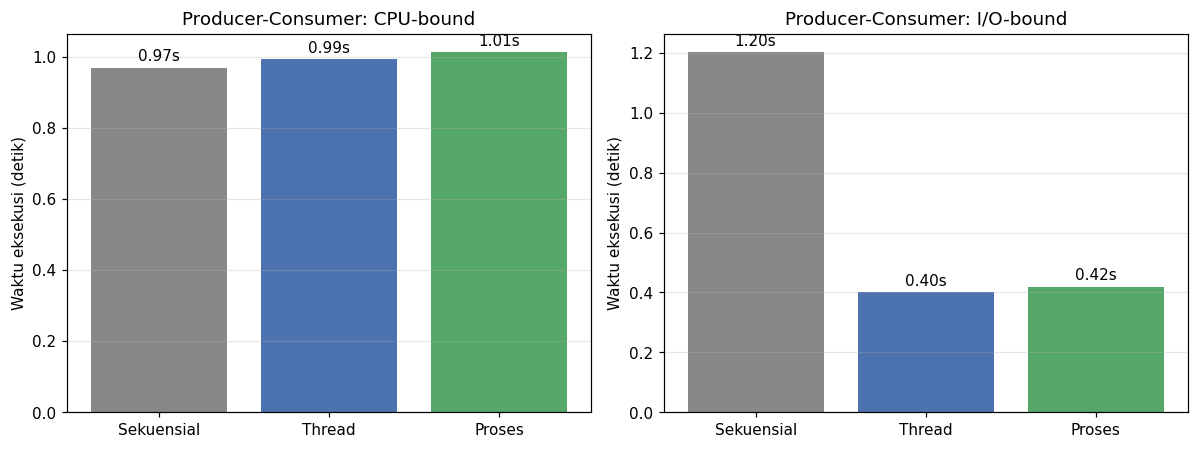

In [7]:
import os
import matplotlib.pyplot as plt

CORE = len(os.sched_getaffinity(0)) if hasattr(os, "sched_getaffinity") else (os.cpu_count() or 1)
print(f"Core tersedia: {CORE}   | Consumer: {JUMLAH_CONSUMER}\n")

def ukur_semua(daftar_item, kerja, ulang=2):
    hasil = {}
    for nama, fungsi in [("Sekuensial", jalankan_sekuensial),
                         ("Thread", jalankan_thread),
                         ("Proses", jalankan_proses)]:
        percobaan = [fungsi(daftar_item, kerja) for _ in range(ulang)]
        waktu = min(w for w, _ in percobaan)
        hasil[nama] = (waktu, percobaan[0][1])
    # semua versi harus menghasilkan output yang sama
    acuan = hasil["Sekuensial"][1]
    assert all(h[1] == acuan for h in hasil.values()), "Hasil antar versi berbeda!"
    return hasil

if __name__ == "__main__":
    # --- CPU-bound: 12 tugas hitung_prima(100_000) ---
    item_cpu = [100_000] * 12
    hasil_cpu = ukur_semua(item_cpu, kerja_cpu)

    # --- I/O-bound: 12 tugas 'sleep 0.1 detik' ---
    item_io = [0.1] * 12
    hasil_io = ukur_semua(item_io, kerja_io)

    for judul, hasil in [("CPU-bound (hitung_prima)", hasil_cpu), ("I/O-bound (sleep 0,1 s)", hasil_io)]:
        print(f"== {judul} ==")
        base = hasil["Sekuensial"][0]
        for nama, (waktu, _) in hasil.items():
            print(f"  {nama:<11}: {waktu:6.2f} detik   speedup = {base / waktu:5.2f}x")
        print()

    # --- grafik ---
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=False)
    for ax, (judul, hasil) in zip(axes, [("CPU-bound", hasil_cpu), ("I/O-bound", hasil_io)]):
        nama = list(hasil)
        waktu = [hasil[n][0] for n in nama]
        bars = ax.bar(nama, waktu, color=["#888888", "#4C72B0", "#55A868"])
        for b, w in zip(bars, waktu):
            ax.text(b.get_x() + b.get_width() / 2, w + 0.01 * max(waktu), f"{w:.2f}s", ha="center", va="bottom")
        ax.set_title(f"Producer-Consumer: {judul}")
        ax.set_ylabel("Waktu eksekusi (detik)")
        ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- ringkasan otomatis sesuai mesin ---
    bc = hasil_cpu["Sekuensial"][0]
    print("Ringkasan CPU-bound:")
    print(f"  Thread vs Sekuensial : {bc / hasil_cpu['Thread'][0]:.2f}x  (GIL: harapannya mendekati 1x, tidak ada percepatan)")
    print(f"  Proses vs Sekuensial : {bc / hasil_cpu['Proses'][0]:.2f}x  (harapan teoritis hingga ~{min(JUMLAH_CONSUMER, CORE)}x pada {CORE} core)")
    if CORE < 2:
        print("  Catatan: mesin ini hanya punya 1 core, jadi proses pun tidak bisa lebih cepat. Ulangi di mesin multi-core untuk melihat percepatannya.")
    bi = hasil_io["Sekuensial"][0]
    print("Ringkasan I/O-bound:")
    print(f"  Thread vs Sekuensial : {bi / hasil_io['Thread'][0]:.2f}x")
    print(f"  Proses vs Sekuensial : {bi / hasil_io['Proses'][0]:.2f}x")

### Penjelasan Soal 3

Pada percobaan ini, contoh producer-consumer dari Pertemuan 2 yang sebelumnya menggunakan thread dimodifikasi menjadi menggunakan multiprocessing.Queue dan multiprocessing.Process. Konsep dasar program sebenarnya masih sama. Producer tetap bertugas memasukkan tugas ke dalam queue, sedangkan consumer mengambil tugas tersebut dan mengerjakannya.

Perubahan utama terdapat pada mekanisme yang digunakan. Pada versi sebelumnya digunakan queue.Queue dan thread, sedangkan pada versi ini digunakan multiprocessing.Queue dan multiprocessing.Process. Dengan menggunakan process, producer dan setiap consumer berjalan sebagai proses yang terpisah.

Pada program terdapat satu producer dan tiga consumer. Producer memasukkan beberapa tugas ke dalam queue, kemudian ketiga consumer mengambil tugas yang tersedia. Karena terdapat beberapa consumer, tugas dapat dibagi ke beberapa proses sehingga beberapa pekerjaan dapat dikerjakan secara bersamaan.

Perubahan ini menjadi lebih penting ketika pekerjaan yang dilakukan bersifat CPU-bound, yaitu pekerjaan yang membutuhkan banyak perhitungan dari CPU. Pada kondisi tersebut, multiprocessing dapat memanfaatkan beberapa core CPU karena setiap proses berjalan secara terpisah.

Hal ini berbeda dengan threading pada Python yang dipengaruhi oleh GIL. Untuk pekerjaan CPU-bound, penggunaan banyak thread tidak dapat memberikan paralelisme penuh dalam eksekusi kode Python. Dengan menggunakan beberapa proses, pekerjaan dapat dijalankan pada core CPU yang berbeda sehingga lebih sesuai untuk pekerjaan yang membutuhkan banyak perhitungan.

Walaupun begitu, penggunaan multiprocessing juga mempunyai overhead, seperti pembuatan proses dan komunikasi antarproses melalui multiprocessing.Queue. Jadi, penggunaan banyak proses tidak selalu membuat waktu eksekusi semakin cepat. Hasilnya tetap bergantung pada jumlah core CPU, jumlah pekerjaan, pembagian tugas, dan kondisi komputer saat program dijalankan.

---
## Soal 4 — Refleksi Singkat (maks. 150 kata): `Manager()` vs `Value`/`Array`

Sebagai dasar argumen trade-off kemudahan vs performa, berikut benchmark kecil: 4 proses masing-masing menambah counter bersama sebanyak
5.000 kali (dilindungi lock), memakai `Value` dan memakai `Manager().Value`.

In [8]:
import multiprocessing as mp
import time

ctx = mp.get_context("fork")
PROSES, OPERASI = 4, 5_000

def tambah_value(total):
    for _ in range(OPERASI):
        with total.get_lock():
            total.value += 1

def tambah_manager(total, lock):
    for _ in range(OPERASI):
        with lock:
            total.value += 1

def ukur_value():
    total = ctx.Value("q", 0)
    ps = [ctx.Process(target=tambah_value, args=(total,)) for _ in range(PROSES)]
    start = time.perf_counter()
    for p in ps: p.start()
    for p in ps: p.join()
    return total.value, time.perf_counter() - start

def ukur_manager():
    with ctx.Manager() as manager:
        total = manager.Value("q", 0)
        lock = manager.Lock()
        ps = [ctx.Process(target=tambah_manager, args=(total, lock)) for _ in range(PROSES)]
        start = time.perf_counter()
        for p in ps: p.start()
        for p in ps: p.join()
        return total.value, time.perf_counter() - start

if __name__ == "__main__":
    harapan = PROSES * OPERASI
    v, t_value = ukur_value()
    m, t_manager = ukur_manager()
    print(f"Total seharusnya: {harapan:,}")
    print(f"Value            : total = {v:,}  waktu = {t_value:.3f} detik  ({'benar' if v == harapan else 'SALAH'})")
    print(f"Manager().Value  : total = {m:,}  waktu = {t_manager:.3f} detik  ({'benar' if m == harapan else 'SALAH'})")
    print(f"\nManager sekitar {t_manager / t_value:.0f}x lebih lambat daripada Value untuk pola akses yang sama.")

Total seharusnya: 20,000
Value            : total = 20,000  waktu = 0.029 detik  (benar)
Manager().Value  : total = 20,000  waktu = 1.889 detik  (benar)

Manager sekitar 64x lebih lambat daripada Value untuk pola akses yang sama.


### Refleksi (maks. 150 kata)

Saya akan memilih Manager() ketika data yang digunakan cukup kompleks, misalnya berupa list atau dictionary yang perlu dibagikan dan diubah oleh beberapa proses. Manager() lebih mudah digunakan karena tidak perlu mengatur shared memory secara langsung.

Sebaliknya, saya akan memilih Value atau Array jika data yang digunakan sederhana, seperti angka atau kumpulan angka, terutama ketika performa lebih diperhatikan. Value dan Array dapat memberikan akses yang lebih langsung, tetapi penggunaannya membutuhkan pengaturan tambahan seperti Lock agar data tidak berubah secara bersamaan.

Jadi, Manager() lebih mengutamakan kemudahan penggunaan untuk data yang kompleks, sedangkan Value/Array lebih cocok untuk data sederhana ketika efisiensi menjadi pertimbangan. Trade-off-nya adalah kemudahan penggunaan dibandingkan performa dan kontrol terhadap data.